### 预测每月每个cluster的销售数量（已完成）

### Connect postgresql database

In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text

# 数据库配置
username = "XXXXXX"
password = "YYYYYY"
host = "localhost"
port = 5432
database = "eyewear-data"

# 创建连接
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)


### Query and cal customer RFM feature

In [ ]:
# 1 . 每月销售额、订单数量和平均订单价值
sale_amount_monthly_sql = """
WITH cluster_region_monthly_quantity AS (
    SELECT
        TO_CHAR(o.order_date,'YYYY-MM') AS order_month,
        c.customer_hierarchy,
        c.customer_type,
        c.region,
        SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) AS region_paid_quantity
    FROM "Order" o
    JOIN "OrderItem" oi ON o.order_id = oi.order_id
    LEFT JOIN "CustomerInfo" c ON o.customer_id = c.customer_id
    WHERE o.order_status IN ('Completed','Shipped')
      AND o.order_date IS NOT NULL 
      AND c.customer_hierarchy IS NOT NULL 
    GROUP BY order_month, c.customer_hierarchy, c.customer_type, c.region
),

-- 地区集中度（基于销量）
cluster_region_rank AS (
    SELECT *,
           RANK() OVER(
           PARTITION BY order_month,customer_hierarchy, customer_type ORDER BY region_paid_quantity DESC
           ) AS region_rank
    FROM cluster_region_monthly_quantity

cluster_region_concentration AS (
    SELECT
        order_month,customer_hierarchy, customer_type,
        MAX(CASE WHEN region_rank = 1 THEN region_paid_quantity END)::numeric 
            / NULLIF(SUM(region_paid_quantity)::numeric, 0) AS top_region_quantity_ratio,
        SUM(CASE WHEN region_rank <=5 THEN region_paid_quantity ELSE 0 END)::numeric 
            / NULLIF(SUM(region_paid_quantity)::numeric, 0) AS top5_region_quantity_ratio
    FROM cluster_region_rank
    GROUP BY order_month, customer_hierarchy, customer_type
),

cluster_region_entropy AS (
    SELECT
        order_month,
        customer_hierarchy,
        customer_type,
        -SUM(qty_share * LN(qty_share)) AS region_paid_qty_entropy
    FROM (
        SELECT
            order_month,
            customer_hierarchy, 
            customer_type,
            region,
            region_paid_quantity::numeric / NULLIF(SUM(region_paid_quantity::numeric) 
            OVER (PARTITION BY order_month, customer_hierarchy, customer_type), 0) AS qty_share
        FROM cluster_region_monthly_quantity
    ) t
    GROUP BY order_month, customer_hierarchy, customer_type
)

SELECT
    to_char(o.order_date, 'YYYY-MM') AS order_month,
    -- 基础指标
    c.customer_hierarchy,
    c.customer_type,

    COUNT(DISTINCT o.order_id) AS order_count,
    COUNT(DISTINCT o.customer_id) AS unique_customer_count,

    SUM(oi.line_price_after_tax) AS monthly_revenue,
    SUM(oi.line_price_before_tax) AS monthly_revenue_before_tax,
    SUM(o.total_price_after_tax)/COUNT(DISTINCT o.order_id) AS avg_order_value,

    -- 目标变量
    SUM(oi.quantity) AS total_quantity,   
    SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) AS customer_paid_quantity, -- ← 预测目标
    
    -- 每个订单平均付费商品数量（推荐）
    SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS avg_paid_qty_per_order,

    -- 每个订单平均总商品数量（包含赠品）
    SUM(oi.quantity)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS avg_total_qty_per_order,

    -- 价格
    SUM(oi.line_price_after_tax)/NULLIF(SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END),0) 
        AS avg_unit_price,

    -- 促销
    COUNT(DISTINCT pa.campaign_id) AS promotion_count,
    COUNT(DISTINCT CASE WHEN o.campaign_id IS NOT NULL THEN o.order_id END) AS promo_order_count,
    -- 促销订单占比（按订单）
    COUNT(DISTINCT CASE WHEN o.campaign_id IS NOT NULL THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS promo_order_ratio,
    
    -- 促销贡献的付费销量占比（推荐使用这个）
    SUM(CASE WHEN o.campaign_id IS NOT NULL 
             THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END)
             ELSE 0 END)::numeric 
        / NULLIF(SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END), 0) 
        AS promo_paid_qty_ratio,

    -- 促销贡献的总销量占比（作为对比）
    SUM(CASE WHEN o.campaign_id IS NOT NULL THEN oi.quantity ELSE 0 END)::numeric 
        / NULLIF(SUM(oi.quantity), 0) AS promo_total_qty_ratio,
      
    AVG(CASE WHEN pa.discount_type='Percentage' THEN pa.discount_value END) AS avg_percentage_discount,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Percentage' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS percentage_discount_order_ratio,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Fixed Amount' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS fixed_amount_discount_order_ratio,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Free Gift' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS free_gift_order_ratio,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Buy One Get One' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS bogo_order_ratio,

    -- 地区
    MAX(rc.top_region_quantity_ratio) AS top_region_quantity_ratio,
    MAX(rc.top5_region_quantity_ratio) AS top5_region_quantity_ratio,
    MAX(re.region_paid_qty_entropy) AS region_paid_qty_entropy,

    -- 产品结构（已使用quantity）
    SUM(CASE WHEN p.category = 'Eyeglasses' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_eyeglasses,

    SUM(CASE WHEN p.category = 'Sunglasses' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_sunglass,

    SUM(CASE WHEN p.category = 'AI Glasses' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_ai_glasses,

    SUM(CASE WHEN p.category = 'Lens' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_lens,

    -- 时间特征
    EXTRACT(YEAR FROM o.order_date) AS year,
    EXTRACT(MONTH FROM o.order_date) AS month,
    CONCAT(EXTRACT(YEAR FROM o.order_date),'-Q',EXTRACT(QUARTER FROM o.order_date)::int) AS quarter,
    CASE 
        WHEN EXTRACT(MONTH FROM o.order_date) IN (12,1,2) THEN 'Winter'
        WHEN EXTRACT(MONTH FROM o.order_date) IN (3,4,5) THEN 'Spring'
        WHEN EXTRACT(MONTH FROM o.order_date) IN (6,7,8) THEN 'Summer'
        ELSE 'Autumn' 
    END AS season

FROM "Order" o
JOIN "OrderItem" oi ON o.order_id = oi.order_id
LEFT JOIN "PromotionActivity" pa ON o.campaign_id = pa.campaign_id
LEFT JOIN "CustomerInfo" c ON o.customer_id = c.customer_id
LEFT JOIN "ProductInfo" p ON oi.product_id = p.product_id
LEFT JOIN cluster_region_concentration rc 
ON rc.order_month = TO_CHAR(o.order_date,'YYYY-MM') 
AND rc.customer_hierarchy = c.customer_hierarchy 
AND rc.customer_type = c.customer_type
LEFT JOIN cluster_region_entropy re 
ON re.order_month = TO_CHAR(o.order_date,'YYYY-MM')
AND re.customer_hierarchy = c.customer_hierarchy 
AND re.customer_type = c.customer_type
WHERE o.order_status IN ('Completed', 'Shipped')
  AND o.order_date IS NOT NULL
  AND p.category <> 'Accessory'

GROUP BY
  to_char(o.order_date, 'YYYY-MM'),
  c.customer_hierarchy,
  c.customer_type,
  EXTRACT(YEAR FROM o.order_date),
  EXTRACT(MONTH FROM o.order_date),
  EXTRACT(QUARTER FROM o.order_date),
  CASE 
    WHEN EXTRACT(MONTH FROM o.order_date) IN (12,1,2) THEN 'Winter'
    WHEN EXTRACT(MONTH FROM o.order_date) IN (3,4,5) THEN 'Spring'
    WHEN EXTRACT(MONTH FROM o.order_date) IN (6,7,8) THEN 'Summer'
    ELSE 'Autumn' 
  END
"""

df_sale_amount_monthly = pd.read_sql(sale_amount_monthly_sql, engine)

df_sale_amount_monthly

,order_month,customer_hierarchy,customer_type,order_count,unique_customer_count,monthly_revenue,monthly_revenue_before_tax,avg_order_value,total_quantity,customer_paid_quantity,...,top5_region_quantity_ratio,region_paid_qty_entropy,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,year,month,quarter,season
0,2023-01,0,Promotional Sensitive Customers,2001,1949,665759.35,607999.21,536.259780,2839,2839,...,0.679112,2.388312,1151,1140,271,277,2023.0,1.0,2023-Q1,Winter
1,2023-01,1,One-time Customers,623,623,285579.30,260803.35,879.969085,1055,1055,...,0.672986,2.427091,455,422,113,65,2023.0,1.0,2023-Q1,Winter
2,2023-01,2,Lens Customers,1135,1098,445361.47,406722.95,636.622344,1678,1678,...,0.692491,2.364125,303,251,54,1070,2023.0,1.0,2023-Q1,Winter
3,2023-01,3,VIP Loyal Customers,6308,5877,2960041.59,2703235.30,925.819469,11217,11217,...,0.694660,2.364026,4034,4007,1144,2032,2023.0,1.0,2023-Q1,Winter
4,2023-01,4,Regular Customers,5694,5485,2305068.61,2105086.57,716.688932,8741,8741,...,0.689509,2.373342,3381,3369,937,1054,2023.0,1.0,2023-Q1,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-12,0,Promotional Sensitive Customers,3644,3512,1239172.00,1131663.72,584.464457,5487,5487,...,0.700383,2.348207,1212,1127,2815,333,2024.0,12.0,2024-Q4,Winter
116,2024-12,1,One-time Customers,740,740,368420.97,336458.00,931.219257,1224,1224,...,0.723856,2.335409,268,256,663,37,2024.0,12.0,2024-Q4,Winter
117,2024-12,2,Lens Customers,887,861,305913.07,279372.65,506.460733,1205,1205,...,0.692946,2.374333,138,124,302,641,2024.0,12.0,2024-Q4,Winter
118,2024-12,3,VIP Loyal Customers,9251,8409,4525041.83,4132460.76,976.775106,16696,16696,...,0.690165,2.371453,3411,3330,8329,1626,2024.0,12.0,2024-Q4,Winter


In [3]:
df_sale_amount_monthly['customer_hierarchy'].unique()

array(['0', '1', '2', '3', '4'], dtype=object)

In [4]:
df_sale_amount_monthly.columns

Index(['order_month', 'customer_hierarchy', 'customer_type', 'order_count',
       'unique_customer_count', 'monthly_revenue',
       'monthly_revenue_before_tax', 'avg_order_value', 'total_quantity',
       'customer_paid_quantity', 'avg_paid_qty_per_order',
       'avg_total_qty_per_order', 'avg_unit_price', 'promotion_count',
       'promo_order_count', 'promo_order_ratio', 'promo_paid_qty_ratio',
       'promo_total_qty_ratio', 'avg_percentage_discount',
       'percentage_discount_order_ratio', 'fixed_amount_discount_order_ratio',
       'free_gift_order_ratio', 'bogo_order_ratio',
       'top_region_quantity_ratio', 'top5_region_quantity_ratio',
       'region_paid_qty_entropy', 'paid_qty_eyeglasses', 'paid_qty_sunglass',
       'paid_qty_ai_glasses', 'paid_qty_lens', 'year', 'month', 'quarter',
       'season'],
      dtype='object')

### cal timeseries feature for sale amount(针对热销产品预测销售数量)

In [5]:
import numpy as np
df_timeseries_features = (
    df_sale_amount_monthly[
        ["order_month", "customer_hierarchy", "customer_type", "customer_paid_quantity","order_count","unique_customer_count"]
    ]
    .sort_values(["order_month", "customer_hierarchy", "customer_type"])
    .copy()
)

df_timeseries_features["trend"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])
    .cumcount()
)


# 基础时间序列特征
for lag in [1, 2, 3, 4, 12]:
    df_timeseries_features[f"lag_{lag}_month_quantity"] = (
        df_timeseries_features
        .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
        .shift(lag)
    )

# 滚动平均
def rolling_mean(s, window):
    return s.shift(1).rolling(window, min_periods=1).mean()


# 计算滚动平均值
df_timeseries_features["rolling_3_month_avg_quantity"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
    .transform(lambda x: rolling_mean(x, 3))
)
df_timeseries_features["rolling_6_month_avg_quantity"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
    .transform(lambda x: rolling_mean(x, 6))
)
df_timeseries_features["rolling_12_month_avg_quantity"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
    .transform(lambda x: rolling_mean(x, 12))
)


# ==================== 新增的3种 Baseline ====================

# 1. Historical Mean（历史均值）
df_timeseries_features["historical_mean"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
    .transform(lambda x: x.expanding().mean())
)
# 2. Historical Median（历史中位数 Baseline）
df_timeseries_features["historical_median"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
    .transform(lambda x: x.expanding().median())
)

# 3. Weighted Moving Average (WMA - 线性加权移动平均)
def weighted_moving_average(x, window=3):
    """线性加权：最近的月份权重最高"""
    if len(x) < window:
        return np.nan
    weights = np.arange(1, window + 1)      # 如 window=3 时权重为 [1,2,3]
    return np.dot(x, weights) / weights.sum()

# 计算 WMA
df_timeseries_features["wma_3"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
    .transform(lambda x: x.shift(1).rolling(3).apply(weighted_moving_average, raw=True))
)

# 指数加权移动平均
df_timeseries_features["ewm_3"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
    .transform(lambda x: x.ewm(span=3,adjust=False).mean())
)

df_timeseries_features["ewm_6"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
    .transform(lambda x: x.ewm(span=6,adjust=False).mean())
)

df_timeseries_features["ewm_alpha"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
    .transform(lambda x: x.ewm(alpha=0.3,adjust=False).mean())
)

# Growth 特征
df_timeseries_features["mom_growth"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
    .transform(lambda x: x.shift(1).pct_change(1))
)

df_timeseries_features["yoy_growth"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["customer_paid_quantity"]
    .transform(lambda x: x.shift(1).pct_change(12))
)

# 加速/减速信号
df_timeseries_features["mom_acceleration"] = (
    df_timeseries_features["mom_growth"]
    -
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["mom_growth"]
    .shift(1)
)

df_timeseries_features["lag_1_order_count"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["order_count"]
    .shift(1)
)

df_timeseries_features["lag_1_customer_count"] = (
    df_timeseries_features
    .groupby(["customer_hierarchy", "customer_type"])["unique_customer_count"]
    .shift(1)
)

df_timeseries_features

,order_month,customer_hierarchy,customer_type,customer_paid_quantity,order_count,unique_customer_count,trend,lag_1_month_quantity,lag_2_month_quantity,lag_3_month_quantity,...,historical_median,wma_3,ewm_3,ewm_6,ewm_alpha,mom_growth,yoy_growth,mom_acceleration,lag_1_order_count,lag_1_customer_count
0,2023-01,0,Promotional Sensitive Customers,2839,2001,1949,0,NaN,NaN,NaN,...,2839.0,NaN,2839.000000,2839.000000,2839.000000,NaN,NaN,NaN,NaN,NaN
1,2023-01,1,One-time Customers,1055,623,623,0,NaN,NaN,NaN,...,1055.0,NaN,1055.000000,1055.000000,1055.000000,NaN,NaN,NaN,NaN,NaN
2,2023-01,2,Lens Customers,1678,1135,1098,0,NaN,NaN,NaN,...,1678.0,NaN,1678.000000,1678.000000,1678.000000,NaN,NaN,NaN,NaN,NaN
3,2023-01,3,VIP Loyal Customers,11217,6308,5877,0,NaN,NaN,NaN,...,11217.0,NaN,11217.000000,11217.000000,11217.000000,NaN,NaN,NaN,NaN,NaN
4,2023-01,4,Regular Customers,8741,5694,5485,0,NaN,NaN,NaN,...,8741.0,NaN,8741.000000,8741.000000,8741.000000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-12,0,Promotional Sensitive Customers,5487,3644,3512,23,5776.0,5950.0,2383.0,...,3025.5,5268.500000,5260.404637,4688.017491,4734.060473,-0.029244,-0.267841,-1.526096,3871.0,3685.0
116,2024-12,1,One-time Customers,1224,740,740,23,1255.0,1343.0,969.0,...,1115.0,1236.666667,1223.708206,1192.301002,1194.927979,-0.065525,-0.269924,-0.451490,764.0,764.0
117,2024-12,2,Lens Customers,1205,887,861,23,1449.0,1438.0,968.0,...,1443.5,1365.166667,1274.863325,1262.891787,1262.493436,0.007650,-0.382090,-0.477888,1052.0,1020.0
118,2024-12,3,VIP Loyal Customers,16696,9251,8409,23,17797.0,18197.0,10779.0,...,12022.0,16760.666667,16487.637116,15370.817458,15464.857467,-0.021982,-0.219875,-0.710172,9905.0,8944.0


In [6]:
df_timeseries_features.columns

Index(['order_month', 'customer_hierarchy', 'customer_type',
       'customer_paid_quantity', 'order_count', 'unique_customer_count',
       'trend', 'lag_1_month_quantity', 'lag_2_month_quantity',
       'lag_3_month_quantity', 'lag_4_month_quantity', 'lag_12_month_quantity',
       'rolling_3_month_avg_quantity', 'rolling_6_month_avg_quantity',
       'rolling_12_month_avg_quantity', 'historical_mean', 'historical_median',
       'wma_3', 'ewm_3', 'ewm_6', 'ewm_alpha', 'mom_growth', 'yoy_growth',
       'mom_acceleration', 'lag_1_order_count', 'lag_1_customer_count'],
      dtype='object')

### merge 2 dataframe

In [ ]:
df_sale_amount_monthly_final = (
    df_sale_amount_monthly
    .merge(
        df_timeseries_features[
            [
                "order_month",
                "customer_hierarchy",
                "customer_type",
                "trend",
                "lag_1_month_quantity",
                "lag_2_month_quantity",
                "lag_3_month_quantity",
                "lag_4_month_quantity",
                "lag_12_month_quantity",
                "rolling_3_month_avg_quantity",
                "rolling_6_month_avg_quantity",
                "rolling_12_month_avg_quantity",
                "historical_mean", 
                "historical_median", 
                "wma_3",
                "ewm_3", 
                "ewm_6", 
                "ewm_alpha",
                "mom_growth",
                "yoy_growth",
                "mom_acceleration",
                "lag_1_order_count",
                "lag_1_customer_count"
            ]
        ],
        on=["order_month","customer_hierarchy","customer_type"],
        how="left"
    )
)

df_sale_amount_monthly_final

,order_month,customer_hierarchy,customer_type,order_count,unique_customer_count,monthly_revenue,monthly_revenue_before_tax,avg_order_value,total_quantity,customer_paid_quantity,...,historical_median,wma_3,ewm_3,ewm_6,ewm_alpha,mom_growth,yoy_growth,mom_acceleration,lag_1_order_count,lag_1_customer_count
0,2023-01,0,Promotional Sensitive Customers,2001,1949,665759.35,607999.21,536.259780,2839,2839,...,2839.0,NaN,2839.000000,2839.000000,2839.000000,NaN,NaN,NaN,NaN,NaN
1,2023-01,1,One-time Customers,623,623,285579.30,260803.35,879.969085,1055,1055,...,1055.0,NaN,1055.000000,1055.000000,1055.000000,NaN,NaN,NaN,NaN,NaN
2,2023-01,2,Lens Customers,1135,1098,445361.47,406722.95,636.622344,1678,1678,...,1678.0,NaN,1678.000000,1678.000000,1678.000000,NaN,NaN,NaN,NaN,NaN
3,2023-01,3,VIP Loyal Customers,6308,5877,2960041.59,2703235.30,925.819469,11217,11217,...,11217.0,NaN,11217.000000,11217.000000,11217.000000,NaN,NaN,NaN,NaN,NaN
4,2023-01,4,Regular Customers,5694,5485,2305068.61,2105086.57,716.688932,8741,8741,...,8741.0,NaN,8741.000000,8741.000000,8741.000000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-12,0,Promotional Sensitive Customers,3644,3512,1239172.00,1131663.72,584.464457,5487,5487,...,3025.5,5268.500000,5260.404637,4688.017491,4734.060473,-0.029244,-0.267841,-1.526096,3871.0,3685.0
116,2024-12,1,One-time Customers,740,740,368420.97,336458.00,931.219257,1224,1224,...,1115.0,1236.666667,1223.708206,1192.301002,1194.927979,-0.065525,-0.269924,-0.451490,764.0,764.0
117,2024-12,2,Lens Customers,887,861,305913.07,279372.65,506.460733,1205,1205,...,1443.5,1365.166667,1274.863325,1262.891787,1262.493436,0.007650,-0.382090,-0.477888,1052.0,1020.0
118,2024-12,3,VIP Loyal Customers,9251,8409,4525041.83,4132460.76,976.775106,16696,16696,...,12022.0,16760.666667,16487.637116,15370.817458,15464.857467,-0.021982,-0.219875,-0.710172,9905.0,8944.0


In [9]:
df_sale_amount_monthly_final.columns

Index(['order_month', 'customer_hierarchy', 'customer_type', 'order_count',
       'unique_customer_count', 'monthly_revenue',
       'monthly_revenue_before_tax', 'avg_order_value', 'total_quantity',
       'customer_paid_quantity', 'avg_paid_qty_per_order',
       'avg_total_qty_per_order', 'avg_unit_price', 'promotion_count',
       'promo_order_count', 'promo_order_ratio', 'promo_paid_qty_ratio',
       'promo_total_qty_ratio', 'avg_percentage_discount',
       'percentage_discount_order_ratio', 'fixed_amount_discount_order_ratio',
       'free_gift_order_ratio', 'bogo_order_ratio',
       'top_region_quantity_ratio', 'top5_region_quantity_ratio',
       'region_paid_qty_entropy', 'paid_qty_eyeglasses', 'paid_qty_sunglass',
       'paid_qty_ai_glasses', 'paid_qty_lens', 'year', 'month', 'quarter',
       'season', 'trend', 'lag_1_month_quantity', 'lag_2_month_quantity',
       'lag_3_month_quantity', 'lag_4_month_quantity', 'lag_12_month_quantity',
       'rolling_3_month_avg_quant

In [ ]:
# 预测的目标值
target_cols = ['customer_paid_quantity']

# 预测需要使用的特征列
feature_cols = [
    "customer_hierarchy", 
    "customer_type",
    'lag_1_month_quantity', 
    'lag_3_month_quantity',
    'rolling_3_month_avg_quantity', 'rolling_6_month_avg_quantity',
    'mom_growth', 'yoy_growth','mom_acceleration',
    
    # 季节与周期
    'month', 'quarter', 
    
    # 促销特征
    'promotion_count', 
    'promo_order_ratio', 
    'promo_paid_qty_ratio',

    'avg_percentage_discount', 
    'percentage_discount_order_ratio',
    'fixed_amount_discount_order_ratio',
    'free_gift_order_ratio',
    'bogo_order_ratio',
    
    # 产品结构
    'paid_qty_eyeglasses',
    'paid_qty_sunglass',
    'paid_qty_ai_glasses',
    'paid_qty_lens',
    
    # 历史业务量
    'lag_1_order_count',
    'lag_1_customer_count',
]

df_sale_predict_dataset = df_sale_amount_monthly_final[['order_month'] + target_cols + feature_cols].copy()
df_sale_predict_dataset

,order_month,customer_paid_quantity,customer_hierarchy,customer_type,lag_1_month_quantity,lag_3_month_quantity,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,mom_growth,yoy_growth,...,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count,lag_1_customer_count
0,2023-01,2839,0,Promotional Sensitive Customers,NaN,NaN,NaN,NaN,NaN,NaN,...,0.621689,0.042979,0.000000,0.0,1151,1140,271,277,NaN,NaN
1,2023-01,1055,1,One-time Customers,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.0,455,422,113,65,NaN,NaN
2,2023-01,1678,2,Lens Customers,NaN,NaN,NaN,NaN,NaN,NaN,...,0.224670,0.022907,0.000000,0.0,303,251,54,1070,NaN,NaN
3,2023-01,11217,3,VIP Loyal Customers,NaN,NaN,NaN,NaN,NaN,NaN,...,0.253329,0.035986,0.000000,0.0,4034,4007,1144,2032,NaN,NaN
4,2023-01,8741,4,Regular Customers,NaN,NaN,NaN,NaN,NaN,NaN,...,0.140323,0.015104,0.000000,0.0,3381,3369,937,1054,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-12,5487,0,Promotional Sensitive Customers,5776.0,2383.0,4703.000000,3811.166667,-0.029244,-0.267841,...,0.767014,0.028814,0.009605,0.0,1212,1127,2815,333,3871.0,3685.0
116,2024-12,1224,1,One-time Customers,1255.0,969.0,1189.000000,1152.500000,-0.065525,-0.269924,...,0.000000,0.000000,0.050000,0.0,268,256,663,37,764.0,764.0
117,2024-12,1205,2,Lens Customers,1449.0,968.0,1285.000000,1190.833333,0.007650,-0.382090,...,0.361894,0.006764,0.012401,0.0,138,124,302,641,1052.0,1020.0
118,2024-12,16696,3,VIP Loyal Customers,17797.0,10779.0,15591.000000,13704.166667,-0.021982,-0.219875,...,0.365690,0.021727,0.035888,0.0,3411,3330,8329,1626,9905.0,8944.0


### Data Validation

In [11]:
# 基本检查
print(df_sale_predict_dataset.shape)
# 缺失值情况
print(df_sale_predict_dataset.isnull().sum())
print(df_sale_predict_dataset.dtypes)

# 相关性（快速看特征重要性）
print(df_sale_predict_dataset.columns.tolist())
revenue_cols = [col for col in df_sale_predict_dataset.columns if 'revenue' in col]
print("所有包含 'revenue' 的列：", revenue_cols)

(120, 27)
order_month                           0
customer_paid_quantity                0
customer_hierarchy                    0
customer_type                         0
lag_1_month_quantity                  5
lag_3_month_quantity                 15
rolling_3_month_avg_quantity          5
rolling_6_month_avg_quantity          5
mom_growth                           10
yoy_growth                           65
mom_acceleration                     15
month                                 0
quarter                               0
promotion_count                       0
promo_order_ratio                     0
promo_paid_qty_ratio                  0
avg_percentage_discount              24
percentage_discount_order_ratio       0
fixed_amount_discount_order_ratio     0
free_gift_order_ratio                 0
bogo_order_ratio                      0
paid_qty_eyeglasses                   0
paid_qty_sunglass                     0
paid_qty_ai_glasses                   0
paid_qty_lens                 

### Imputing Missing Values

In [ ]:
df_filled = df_sale_predict_dataset.sort_values(
    ['customer_hierarchy','customer_type', 'order_month']
).copy()

lag_cols = [
    'lag_1_month_quantity',
    'lag_3_month_quantity',
    'lag_1_order_count',
]
rolling_cols = [
    'rolling_3_month_avg_quantity',
    'rolling_6_month_avg_quantity',
]

growth_cols = ['mom_growth']
# 1) 时间序列特征：按产品时间前向填，再补 0
ts_cols = lag_cols + rolling_cols
df_filled[ts_cols] = df_filled.groupby(['customer_hierarchy', 'customer_type'])[ts_cols].ffill()
df_filled[ts_cols] = df_filled[ts_cols].fillna(0)

# 2) 增长率：未知视为 0
df_filled[growth_cols] = df_filled[growth_cols].fillna(0)

# 3) 促销折扣均值：无折扣视为 0
if 'avg_percentage_discount' in df_filled.columns:
    df_filled['avg_percentage_discount'] = (
        df_filled['avg_percentage_discount'].fillna(0)
    )

print(df_filled.isnull().sum())
df_final = df_filled.sort_values('order_month').reset_index(drop=True)
df_final

order_month                           0
customer_paid_quantity                0
customer_hierarchy                    0
customer_type                         0
lag_1_month_quantity                  0
lag_3_month_quantity                  0
rolling_3_month_avg_quantity          0
rolling_6_month_avg_quantity          0
mom_growth                            0
yoy_growth                           65
mom_acceleration                     15
month                                 0
quarter                               0
promotion_count                       0
promo_order_ratio                     0
promo_paid_qty_ratio                  0
avg_percentage_discount               0
percentage_discount_order_ratio       0
fixed_amount_discount_order_ratio     0
free_gift_order_ratio                 0
bogo_order_ratio                      0
paid_qty_eyeglasses                   0
paid_qty_sunglass                     0
paid_qty_ai_glasses                   0
paid_qty_lens                         0


,order_month,customer_paid_quantity,customer_hierarchy,customer_type,lag_1_month_quantity,lag_3_month_quantity,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,mom_growth,yoy_growth,...,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count,lag_1_customer_count
0,2023-01,2839,0,Promotional Sensitive Customers,0.0,0.0,0.000000,0.000000,0.000000,NaN,...,0.621689,0.042979,0.000000,0.0,1151,1140,271,277,0.0,NaN
1,2023-01,8741,4,Regular Customers,0.0,0.0,0.000000,0.000000,0.000000,NaN,...,0.140323,0.015104,0.000000,0.0,3381,3369,937,1054,0.0,NaN
2,2023-01,1055,1,One-time Customers,0.0,0.0,0.000000,0.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.0,455,422,113,65,0.0,NaN
3,2023-01,11217,3,VIP Loyal Customers,0.0,0.0,0.000000,0.000000,0.000000,NaN,...,0.253329,0.035986,0.000000,0.0,4034,4007,1144,2032,0.0,NaN
4,2023-01,1678,2,Lens Customers,0.0,0.0,0.000000,0.000000,0.000000,NaN,...,0.224670,0.022907,0.000000,0.0,303,251,54,1070,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-12,16696,3,VIP Loyal Customers,17797.0,10779.0,15591.000000,13704.166667,-0.021982,-0.219875,...,0.365690,0.021727,0.035888,0.0,3411,3330,8329,1626,9905.0,8944.0
116,2024-12,1224,1,One-time Customers,1255.0,969.0,1189.000000,1152.500000,-0.065525,-0.269924,...,0.000000,0.000000,0.050000,0.0,268,256,663,37,764.0,764.0
117,2024-12,5487,0,Promotional Sensitive Customers,5776.0,2383.0,4703.000000,3811.166667,-0.029244,-0.267841,...,0.767014,0.028814,0.009605,0.0,1212,1127,2815,333,3871.0,3685.0
118,2024-12,1205,2,Lens Customers,1449.0,968.0,1285.000000,1190.833333,0.007650,-0.382090,...,0.361894,0.006764,0.012401,0.0,138,124,302,641,1052.0,1020.0


### Imputing Missing Values debug 1

In [ ]:
df_filled = df_sale_predict_dataset.sort_values(
    ['customer_hierarchy','customer_type', 'order_month']
).copy()

# 增长率：未知 → 0（可选）
# growth_cols = ['mom_growth', 'yoy_growth', 'mom_acceleration']
growth_cols = ['mom_growth']
df_filled[growth_cols] = df_filled[growth_cols].fillna(0)

# 无百分比折扣 → 0
# df_filled['avg_percentage_discount'] = df_filled['avg_percentage_discount'].fillna(0)

# lag / rolling：保留 NaN，交给 LightGBM/CatBoost
# 不要 numeric_cols.fillna(0)

df_final = df_filled.sort_values(['order_month']).reset_index(drop=True)
df_final

,order_month,customer_paid_quantity,customer_hierarchy,customer_type,lag_1_month_quantity,lag_3_month_quantity,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,mom_growth,yoy_growth,...,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count,lag_1_customer_count
0,2023-01,2839,0,Promotional Sensitive Customers,NaN,NaN,NaN,NaN,0.000000,NaN,...,0.621689,0.042979,0.000000,0.0,1151,1140,271,277,NaN,NaN
1,2023-01,8741,4,Regular Customers,NaN,NaN,NaN,NaN,0.000000,NaN,...,0.140323,0.015104,0.000000,0.0,3381,3369,937,1054,NaN,NaN
2,2023-01,1055,1,One-time Customers,NaN,NaN,NaN,NaN,0.000000,NaN,...,0.000000,0.000000,0.000000,0.0,455,422,113,65,NaN,NaN
3,2023-01,11217,3,VIP Loyal Customers,NaN,NaN,NaN,NaN,0.000000,NaN,...,0.253329,0.035986,0.000000,0.0,4034,4007,1144,2032,NaN,NaN
4,2023-01,1678,2,Lens Customers,NaN,NaN,NaN,NaN,0.000000,NaN,...,0.224670,0.022907,0.000000,0.0,303,251,54,1070,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-12,16696,3,VIP Loyal Customers,17797.0,10779.0,15591.000000,13704.166667,-0.021982,-0.219875,...,0.365690,0.021727,0.035888,0.0,3411,3330,8329,1626,9905.0,8944.0
116,2024-12,1224,1,One-time Customers,1255.0,969.0,1189.000000,1152.500000,-0.065525,-0.269924,...,0.000000,0.000000,0.050000,0.0,268,256,663,37,764.0,764.0
117,2024-12,5487,0,Promotional Sensitive Customers,5776.0,2383.0,4703.000000,3811.166667,-0.029244,-0.267841,...,0.767014,0.028814,0.009605,0.0,1212,1127,2815,333,3871.0,3685.0
118,2024-12,1205,2,Lens Customers,1449.0,968.0,1285.000000,1190.833333,0.007650,-0.382090,...,0.361894,0.006764,0.012401,0.0,138,124,302,641,1052.0,1020.0


In [14]:
# 基本检查
print(df_final.shape)
# 缺失值情况
print(df_final.isnull().sum())

(120, 27)
order_month                           0
customer_paid_quantity                0
customer_hierarchy                    0
customer_type                         0
lag_1_month_quantity                  5
lag_3_month_quantity                 15
rolling_3_month_avg_quantity          5
rolling_6_month_avg_quantity          5
mom_growth                            0
yoy_growth                           65
mom_acceleration                     15
month                                 0
quarter                               0
promotion_count                       0
promo_order_ratio                     0
promo_paid_qty_ratio                  0
avg_percentage_discount              24
percentage_discount_order_ratio       0
fixed_amount_discount_order_ratio     0
free_gift_order_ratio                 0
bogo_order_ratio                      0
paid_qty_eyeglasses                   0
paid_qty_sunglass                     0
paid_qty_ai_glasses                   0
paid_qty_lens                 

### check `df_final_coverted` data

In [ ]:
# ==================== 数据类型转换（在分割之前） ====================
df_final_converted = df_final.copy()

# 先检查原始数据
print("转换前的数据类型:")
print(df_final_converted[['quarter' ]].dtypes)
print("\n转换前的唯一值:")
print("Quarter 唯一值:", df_final_converted['quarter'].unique())
print("\n是否存在空值:")
print(df_final_converted[['quarter']].isnull().sum())

# 2. 转换 quarter: 从 '2023-Q1' 提取季度数字 1-4
if df_final_converted['quarter'].dtype == 'object':
    # 方法1: 使用 str[0] 参数（推荐）
    df_final_converted['quarter'] = df_final_converted['quarter'].str.extract(r'Q(\d)', expand=False).astype(int)
    print("Quarter 转换完成")
else:
    print("\nWarning: quarter 列不是 object 类型")

# 验证转换结果
print("\n转换后的数据类型:")
print(df_final_converted[['quarter']].dtypes)
print("\n转换后的样例:")
print(df_final_converted[['order_month', 'quarter']].head(10))
print("\n转换后的唯一值:")
print("Quarter:", sorted(df_final_converted['quarter'].unique()))

# 使用转换后的数据进行分割
df_final = df_final_converted


转换前的数据类型:
quarter    object
dtype: object

转换前的唯一值:
Quarter 唯一值: ['2023-Q1' '2023-Q2' '2023-Q3' '2023-Q4' '2024-Q1' '2024-Q2' '2024-Q3'
 '2024-Q4']

是否存在空值:
quarter    0
dtype: int64
Quarter 转换完成

转换后的数据类型:
quarter    int64
dtype: object

转换后的样例:
  order_month  quarter
0     2023-01        1
1     2023-01        1
2     2023-01        1
3     2023-01        1
4     2023-01        1
5     2023-02        1
6     2023-02        1
7     2023-02        1
8     2023-02        1
9     2023-02        1

转换后的唯一值:
Quarter: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### split dataset

In [ ]:
# 24个月数据建议划分:
# 训练集: 前18个月 (2023-01 ~ 2024-06)
# 测试集: 后6个月 (2024-07 ~ 2024-12)
# 这样可以保留约25%数据用于测试,符合业务季节性验证

# 按月份划分：最后 6 个自然月做测试集
n_test_months = 6

months = sorted(df_final['order_month'].unique())
print("全部月份数:", len(months))
print("月份范围:", months[0], "~", months[-1])

if len(months) <= n_test_months:
    raise ValueError(f"月份总数 {len(months)} 不足以留出 {n_test_months} 个月测试集")

train_months = months[:-n_test_months]
test_months = months[-n_test_months:]

train = df_final[df_final['order_month'].isin(train_months)].copy()
test = df_final[df_final['order_month'].isin(test_months)].copy()

# 保持时间顺序（可选再按 product_id）
train = train.sort_values(['order_month',  'customer_hierarchy', 'customer_type']).reset_index(drop=True)
test = test.sort_values(['order_month',  'customer_hierarchy', 'customer_type']).reset_index(drop=True)

print("训练集月份:", train['order_month'].min(), "~", train['order_month'].max())
print("测试集月份:", test['order_month'].min(), "~", test['order_month'].max())
print("训练月份列表:", train_months)
print("测试月份列表:", test_months)
print(f"训练集大小: {len(train)}, 测试集大小: {len(test)}")
print("训练集 cluster 数:", 
      train[['customer_hierarchy', 'customer_type']].drop_duplicates().shape[0])
print("测试集 cluster 数:", 
      test[['customer_hierarchy', 'customer_type']].drop_duplicates().shape[0])


全部月份数: 24
月份范围: 2023-01 ~ 2024-12
训练集月份: 2023-01 ~ 2024-06
测试集月份: 2024-07 ~ 2024-12
训练月份列表: ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06']
测试月份列表: ['2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']
训练集大小: 90, 测试集大小: 30
训练集 cluster 数: 5
测试集 cluster 数: 5


In [17]:
train

,order_month,customer_paid_quantity,customer_hierarchy,customer_type,lag_1_month_quantity,lag_3_month_quantity,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,mom_growth,yoy_growth,...,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count,lag_1_customer_count
0,2023-01,2839,0,Promotional Sensitive Customers,NaN,NaN,NaN,NaN,0.000000,NaN,...,0.621689,0.042979,0.000000,0.0,1151,1140,271,277,NaN,NaN
1,2023-01,1055,1,One-time Customers,NaN,NaN,NaN,NaN,0.000000,NaN,...,0.000000,0.000000,0.000000,0.0,455,422,113,65,NaN,NaN
2,2023-01,1678,2,Lens Customers,NaN,NaN,NaN,NaN,0.000000,NaN,...,0.224670,0.022907,0.000000,0.0,303,251,54,1070,NaN,NaN
3,2023-01,11217,3,VIP Loyal Customers,NaN,NaN,NaN,NaN,0.000000,NaN,...,0.253329,0.035986,0.000000,0.0,4034,4007,1144,2032,NaN,NaN
4,2023-01,8741,4,Regular Customers,NaN,NaN,NaN,NaN,0.000000,NaN,...,0.140323,0.015104,0.000000,0.0,3381,3369,937,1054,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,2024-06,3440,0,Promotional Sensitive Customers,3849.0,2318.0,3294.000000,3671.500000,0.036070,0.517744,...,0.732150,0.000000,0.009492,0.0,879,766,1584,211,2672.0,2601.0
86,2024-06,1088,1,One-time Customers,1225.0,727.0,1026.666667,1050.500000,0.085993,0.111615,...,0.000000,0.000000,0.058917,0.0,261,269,513,45,727.0,727.0
87,2024-06,1103,2,Lens Customers,1369.0,1010.0,1215.000000,1337.333333,0.081359,-0.204070,...,0.318519,0.000000,0.017284,0.0,147,100,248,608,959.0,938.0
88,2024-06,12366,3,VIP Loyal Customers,14346.0,8550.0,12124.000000,12466.833333,0.064559,0.250632,...,0.313269,0.000000,0.046303,0.0,2686,2652,5621,1407,7967.0,7246.0


In [18]:
train.columns

Index(['order_month', 'customer_paid_quantity', 'customer_hierarchy',
       'customer_type', 'lag_1_month_quantity', 'lag_3_month_quantity',
       'rolling_3_month_avg_quantity', 'rolling_6_month_avg_quantity',
       'mom_growth', 'yoy_growth', 'mom_acceleration', 'month', 'quarter',
       'promotion_count', 'promo_order_ratio', 'promo_paid_qty_ratio',
       'avg_percentage_discount', 'percentage_discount_order_ratio',
       'fixed_amount_discount_order_ratio', 'free_gift_order_ratio',
       'bogo_order_ratio', 'paid_qty_eyeglasses', 'paid_qty_sunglass',
       'paid_qty_ai_glasses', 'paid_qty_lens', 'lag_1_order_count',
       'lag_1_customer_count'],
      dtype='object')

In [19]:
test

,order_month,customer_paid_quantity,customer_hierarchy,customer_type,lag_1_month_quantity,lag_3_month_quantity,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,mom_growth,yoy_growth,...,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count,lag_1_customer_count
0,2024-07,2623,0,Promotional Sensitive Customers,3440.0,3715.0,3668.000000,3102.166667,-0.106261,0.436326,...,0.582586,0.064908,0.000000,0.042744,631,670,1151,171,2423.0,2330.0
1,2024-07,1169,1,One-time Customers,1088.0,1128.0,1147.000000,953.333333,-0.111837,0.127461,...,0.000000,0.001486,0.000000,0.095097,295,322,504,48,628.0,628.0
2,2024-07,1102,2,Lens Customers,1103.0,1266.0,1246.000000,1136.333333,-0.194302,-0.210451,...,0.224439,0.012469,0.000000,0.048628,174,119,210,599,810.0,793.0
3,2024-07,11408,3,VIP Loyal Customers,12366.0,13476.0,13396.000000,11097.000000,-0.138018,0.190183,...,0.217220,0.044076,0.000000,0.079779,2765,2539,4681,1423,6911.0,6416.0
4,2024-07,8778,4,Regular Customers,9049.0,9762.0,9769.666667,8073.833333,-0.138026,0.149663,...,0.128331,0.013499,0.000000,0.066620,2199,2157,3687,735,5968.0,5727.0
5,2024-08,2695,0,Promotional Sensitive Customers,2623.0,3849.0,3304.000000,3091.166667,-0.237500,-0.231918,...,0.568345,0.064748,0.000000,0.038541,662,686,1164,183,1895.0,1851.0
6,2024-08,1091,1,One-time Customers,1169.0,1225.0,1160.666667,1014.333333,0.074449,-0.215962,...,0.000000,0.000000,0.000000,0.111465,281,264,497,49,673.0,673.0
7,2024-08,1085,2,Lens Customers,1102.0,1369.0,1191.333333,1146.166667,-0.000907,-0.467118,...,0.233750,0.016250,0.000000,0.052500,144,117,199,625,802.0,785.0
8,2024-08,11678,3,VIP Loyal Customers,11408.0,14346.0,12706.666667,11507.666667,-0.077470,-0.267121,...,0.215828,0.040728,0.000000,0.077600,2697,2747,4768,1466,6330.0,5916.0
9,2024-08,8649,4,Regular Customers,8778.0,10498.0,9441.666667,8434.000000,-0.029948,-0.303831,...,0.127446,0.016570,0.000000,0.074211,2214,2183,3551,701,5704.0,5475.0


In [20]:
test.columns

Index(['order_month', 'customer_paid_quantity', 'customer_hierarchy',
       'customer_type', 'lag_1_month_quantity', 'lag_3_month_quantity',
       'rolling_3_month_avg_quantity', 'rolling_6_month_avg_quantity',
       'mom_growth', 'yoy_growth', 'mom_acceleration', 'month', 'quarter',
       'promotion_count', 'promo_order_ratio', 'promo_paid_qty_ratio',
       'avg_percentage_discount', 'percentage_discount_order_ratio',
       'fixed_amount_discount_order_ratio', 'free_gift_order_ratio',
       'bogo_order_ratio', 'paid_qty_eyeglasses', 'paid_qty_sunglass',
       'paid_qty_ai_glasses', 'paid_qty_lens', 'lag_1_order_count',
       'lag_1_customer_count'],
      dtype='object')

### Separation of features and objectives

In [ ]:
target_qty = 'customer_paid_quantity'   # 或 customer_paid_quantity

# feature_cols 已在上面定义了

# 分离特征和目标
X_train = train[feature_cols].copy()
y_train_qty = train[target_qty].copy()

X_test = test[feature_cols].copy()
y_test_qty = test[target_qty].copy()


In [22]:
X_train

,customer_hierarchy,customer_type,lag_1_month_quantity,lag_3_month_quantity,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,mom_growth,yoy_growth,mom_acceleration,month,...,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,lag_1_order_count,lag_1_customer_count
0,0,Promotional Sensitive Customers,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,...,0.621689,0.042979,0.000000,0.0,1151,1140,271,277,NaN,NaN
1,1,One-time Customers,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,...,0.000000,0.000000,0.000000,0.0,455,422,113,65,NaN,NaN
2,2,Lens Customers,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,...,0.224670,0.022907,0.000000,0.0,303,251,54,1070,NaN,NaN
3,3,VIP Loyal Customers,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,...,0.253329,0.035986,0.000000,0.0,4034,4007,1144,2032,NaN,NaN
4,4,Regular Customers,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,...,0.140323,0.015104,0.000000,0.0,3381,3369,937,1054,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0,Promotional Sensitive Customers,3849.0,2318.0,3294.000000,3671.500000,0.036070,0.517744,-0.566605,6.0,...,0.732150,0.000000,0.009492,0.0,879,766,1584,211,2672.0,2601.0
86,1,One-time Customers,1225.0,727.0,1026.666667,1050.500000,0.085993,0.111615,-0.465589,6.0,...,0.000000,0.000000,0.058917,0.0,261,269,513,45,727.0,727.0
87,2,Lens Customers,1369.0,1010.0,1215.000000,1337.333333,0.081359,-0.204070,-0.172107,6.0,...,0.318519,0.000000,0.017284,0.0,147,100,248,608,959.0,938.0
88,3,VIP Loyal Customers,14346.0,8550.0,12124.000000,12466.833333,0.064559,0.250632,-0.511581,6.0,...,0.313269,0.000000,0.046303,0.0,2686,2652,5621,1407,7967.0,7246.0


In [23]:
y_train_qty

0      2839
1      1055
2      1678
3     11217
4      8741
      ...  
85     3440
86     1088
87     1103
88    12366
89     9049
Name: customer_paid_quantity, Length: 90, dtype: int64

### Run LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


# 训练模型(使用early_stopping代替验证集)
lgm_model_qty = lgb.LGBMRegressor(
    n_estimators=300,          # 增加
    learning_rate=0.1,        # 明显提高（0.05~0.1 区间先试）
    max_depth=5,               # 适度增加
    num_leaves=47,             # 关键！提升到 31~63
    min_child_samples=8,       # 别太高
    min_child_weight=0.001,
    reg_alpha=0.1,             # 大幅降低
    reg_lambda=0.5,            # 大幅降低
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    verbose=-1
)

cat_features = ['product_id', 'category']  # product_id 也可当类别

for col in cat_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

# 保证测试集类别与训练集一致（避免未见类别）
if 'category' in X_train.columns:
    X_test['category'] = pd.Categorical(
        X_test['category'],
        categories=X_train['category'].cat.categories
    )


# 使用eval_set监控测试集表现(但不用于早停,仅用于观察)
lgm_model_qty.fit(
    X_train, y_train_qty,
    eval_X=X_test,        # 替代 eval_set
    eval_y=y_test_qty,    # 替代 eval_set
    eval_metric='mape',
)

# 预测和评估
lgm_pred_qty = lgm_model_qty.predict(X_test)
lgm_pred_qty_final = lgm_pred_qty

lgm_mape = mean_absolute_percentage_error(y_test_qty, lgm_pred_qty_final)
lgm_mae = mean_absolute_error(y_test_qty, lgm_pred_qty_final)
lgm_bias = (lgm_pred_qty_final.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"Bias: {lgm_bias:.2%}")
print(f"Revenue MAPE: {lgm_mape:.2%}")
print(f"Revenue MAE: ${lgm_mae:,.2f}")

# ========== Bias 校准 ==========
# 计算训练集上的系统偏差
lgm_train_pred = lgm_model_qty.predict(X_train)
lgm_train_bias = (lgm_train_pred - y_train_qty).mean()
print(f"\n训练集平均偏差: ${lgm_train_bias:,.0f}")

# 校准测试集预测
lgm_pred_qty_calibrated = lgm_pred_qty - lgm_train_bias

# ====================================

print("lgm_pred_qty:",lgm_pred_qty_final)
print("y_test_qty:",y_test_qty.values)

print("lgm_pred_qty min:", lgm_pred_qty_final.min())
print("lgm_pred_qty max:", lgm_pred_qty_final.max())

print("y_test_qty min:", y_test_qty.min())
print("y_test_qty max:", y_test_qty.max())

Bias: -2.35%
Revenue MAPE: 7.01%
Revenue MAE: $15.23

训练集平均偏差: $-0
lgm_pred_qty: [216.2455403  216.19952285 128.50235585 217.83603993 216.82032321
 219.07499703 220.31065452 112.1946332  135.91922904 219.10917819
 114.72961677 216.73468916 217.56262551 114.34897455 224.33447668
 218.58822985 215.74162686 220.83209955 224.15133068 221.655139
 216.0869298  220.0422074  122.94462545 219.30175056 216.11478031
 217.91314241 219.62181168 110.63339582 119.35844851 219.72484801
 136.20390597 224.61658356 221.38473784 116.40404539 223.76335024
 215.58248773 223.1249323  218.64983143 216.69894697 214.84000589
 221.28619414 220.19357816 111.27825701 217.19086572 220.07919407
 218.9577528  221.9663832  111.07836931 122.63827864 222.23957246
 120.02219617 220.61835312 223.55448588 113.80457812 220.33452964
 220.80005889 221.44806553 225.61859935 220.37311474 213.50941051
 438.40980322 409.15637478 159.32661747 451.93541811 454.47573848
 454.36594658 453.45251315 150.15613192 156.25343971 451.945854

### debug run lightgbm + optuna

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import optuna

# ---------- 1) 训练期内再切验证（按月，不是按行）----------
n_val_months = 3  # 例如 2024-04~06 做 val，更早做 train_inner

train_months_sorted = sorted(train['order_month'].unique())
if len(train_months_sorted) <= n_val_months + 3:
    raise ValueError("训练月份太少，无法再切验证集")

inner_train_months = train_months_sorted[:-n_val_months]
val_months = train_months_sorted[-n_val_months:]

tr_mask = train['order_month'].isin(inner_train_months)
va_mask = train['order_month'].isin(val_months)

X_tr = X_train.loc[tr_mask].copy()
y_tr = y_train_qty.loc[tr_mask].copy()
X_va = X_train.loc[va_mask].copy()
y_va = y_train_qty.loc[va_mask].copy()

# 类别特征（与主流程一致）
cat_features = [c for c in ['customer_hierarchy', 'customer_type', 'quarter', 'month'] if c in X_tr.columns]

def cast_categorical(df, cat_cols, ref_df=None):
    """把类别列转成 category；若给了 ref_df，则用其 categories 对齐"""
    out = df.copy()
    for col in cat_cols:
        if ref_df is None:
            out[col] = out[col].astype("category")
        else:
            out[col] = pd.Categorical(
                out[col],
                categories=ref_df[col].astype("category").cat.categories
            )
    return out

X_tr = cast_categorical(X_tr, cat_features)
X_va = cast_categorical(X_va, cat_features, ref_df=X_tr)

print("inner train:", inner_train_months[0], "~", inner_train_months[-1], "n=", len(X_tr))
print("valid months:", val_months, "n=", len(X_va))
print("cat_features:", cat_features)



def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.12, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 5),          # 样本少，限制深度
        "num_leaves": trial.suggest_int("num_leaves", 8, 31),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 20),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 3.0),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "min_child_weight": 1e-3,
    }
    
    model = lgb.LGBMRegressor(**params, random_state=42, verbose=-1)
    model.fit(
        X_tr, y_tr,
        eval_X=X_va,           
        eval_y=y_va,           
        eval_metric='mape',
        categorical_feature=cat_features,
        callbacks=[lgb.early_stopping(80, verbose=False)]   # 加入早停
    )
    pred = model.predict(X_va)
    return mean_absolute_percentage_error(y_va, pred)

# ====================== 运行 Optuna ======================
print("开始 Optuna 调参...")
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

print("Best MAPE:", study.best_value)
print("Best params:", study.best_params)

# ====================== 使用最优参数训练最终模型 ======================
best_params = study.best_params.copy()

# 类别：全量 train + test
X_train_fit = cast_categorical(X_train.copy(), cat_features)
X_test_fit = cast_categorical(X_test.copy(), cat_features, ref_df=X_train_fit)

lgm_model_qty = lgb.LGBMRegressor(
    **best_params,
    random_state=42,
    verbose=-1
)

# 预测和评估
# 最终训练
lgm_model_qty.fit(X_train_fit, y_train_qty)

# ---------- 4) 测试集只评估一次 ----------
lgm_pred_qty_final = lgm_model_qty.predict(X_test_fit)

lgm_mape = mean_absolute_percentage_error(y_test_qty, lgm_pred_qty_final)
lgm_mae = mean_absolute_error(y_test_qty, lgm_pred_qty_final)
lgm_bias = (lgm_pred_qty_final.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"TEST Bias: {lgm_bias:.2%}")
print(f"TEST MAPE: {lgm_mape:.2%}")
print(f"TEST MAE: {lgm_mae:,.2f}")
# 偏差校准
lgm_train_pred = lgm_model_qty.predict(X_train_fit)
lgm_train_bias = (lgm_train_pred - y_train_qty).mean()
print(f"训练集平均偏差: ${lgm_train_bias:,.0f}")

lgm_pred_qty_calibrated = lgm_pred_qty_final - lgm_train_bias

print("\n=== 最终预测 vs 真实值 ===")
print("预测值:", np.round(lgm_pred_qty_final, 2))
print("真实值:", y_test_qty.values)
print("预测范围:", lgm_pred_qty_final.min(), "→", lgm_pred_qty_final.max())

d:\miniconda_envs\junliangvenv1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-24 14:36:48,531] A new study created in memory with name: no-name-12a48ca8-50bd-425f-820b-4695419eca9a


inner train: 2023-01 ~ 2024-03 n= 75
valid months: ['2024-04', '2024-05', '2024-06'] n= 15
cat_features: ['customer_hierarchy', 'customer_type', 'quarter', 'month']
开始 Optuna 调参...


[I 2026-08-24 14:36:51,415] Trial 0 finished with value: 0.18027927912394284 and parameters: {'n_estimators': 250, 'learning_rate': 0.11207488496994687, 'max_depth': 5, 'num_leaves': 22, 'min_child_samples': 7, 'reg_alpha': 0.3119890406724053, 'reg_lambda': 0.17425083650459838, 'subsample': 0.9598528437324805, 'colsample_bytree': 0.8803345035229626}. Best is trial 0 with value: 0.18027927912394284.
[I 2026-08-24 14:36:51,440] Trial 1 finished with value: 0.29658436128093507 and parameters: {'n_estimators': 383, 'learning_rate': 0.030868416765126767, 'max_depth': 5, 'num_leaves': 27, 'min_child_samples': 8, 'reg_alpha': 0.36364993441420124, 'reg_lambda': 0.5502135295603015, 'subsample': 0.7912726728878613, 'colsample_bytree': 0.8574269294896714}. Best is trial 0 with value: 0.18027927912394284.
[I 2026-08-24 14:36:51,468] Trial 2 finished with value: 0.253582179519029 and parameters: {'n_estimators': 273, 'learning_rate': 0.04492195705620086, 'max_depth': 4, 'num_leaves': 11, 'min_child

Best MAPE: 0.08799153598219672
Best params: {'n_estimators': 497, 'learning_rate': 0.03803138279958639, 'max_depth': 3, 'num_leaves': 17, 'min_child_samples': 6, 'reg_alpha': 1.4324661283995224, 'reg_lambda': 2.6208279505146215, 'subsample': 0.8169776914961426, 'colsample_bytree': 0.8069336449383127}
TEST Bias: -0.70%
TEST MAPE: 17.67%
TEST MAE: 775.34
训练集平均偏差: $-0

=== 最终预测 vs 真实值 ===
预测值: [ 2979.27  1227.22  1489.41 10584.84  9025.35  3028.2   1118.57  1405.61
 11693.9   9901.8   2717.89  1113.17  1408.44 11446.17  7182.46  4413.33
  1217.82  2000.78 15009.23 13215.94  4584.86  1220.24  2170.18 15490.96
 11915.66  4374.38  1141.94  2007.02 15362.8  11311.44]
真实值: [ 2623  1169  1102 11408  8778  2695  1091  1085 11678  8649  2383   969
   968 10779  7723  5950  1343  1438 18197 11181  5776  1255  1449 17797
 10914  5487  1224  1205 16696 10033]
预测范围: 1113.1700218123117 → 15490.962364696476


### catboost + optuna (second best choice)

In [ ]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import optuna

# ---------- 1) 训练期内按月切验证（与 LGBM 一致）----------
n_val_months = 3

train_months_sorted = sorted(train['order_month'].unique())
if len(train_months_sorted) <= n_val_months + 3:
    raise ValueError("训练月份太少，无法再切验证集")

inner_train_months = train_months_sorted[:-n_val_months]
val_months = train_months_sorted[-n_val_months:]

tr_mask = train['order_month'].isin(inner_train_months)
va_mask = train['order_month'].isin(val_months)

X_tr = X_train.loc[tr_mask].copy()
y_tr = y_train_qty.loc[tr_mask].copy()
X_va = X_train.loc[va_mask].copy()
y_va = y_train_qty.loc[va_mask].copy()

# CatBoost 类别特征：用列名字符串即可（不必先 astype category）
# 类别特征：先定义，再转换（避免用未定义的 X_train_fit）
cat_features = [
    c for c in ['customer_hierarchy', 'customer_type']
    if c in X_tr.columns
]

def cast_categorical(df, cat_cols, ref_df=None):
    out = df.copy()
    for col in cat_cols:
        # 关键：先转成 str，避免 1.0 这种 float 类别
        out[col] = out[col].astype(str)
    if ref_df is None:
        for col in cat_cols:
            out[col] = out[col].astype("category")
    else:
        for col in cat_cols:
            out[col] = pd.Categorical(
                out[col],
                categories=ref_df[col].astype("category").cat.categories
            )
    return out

X_tr = cast_categorical(X_tr, cat_features)
X_va = cast_categorical(X_va, cat_features, ref_df=X_tr)


# ====================== Optuna Objective for CatBoost ======================
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 400, 1500),  # 样本不大，不必到 2000
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
        'depth': trial.suggest_int('depth', 3, 6),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 25),
        'subsample': trial.suggest_float('subsample', 0.7, 0.95),
        'random_strength': trial.suggest_float('random_strength', 0.5, 2.5),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.5),
        'grow_policy': trial.suggest_categorical(
            'grow_policy', ['SymmetricTree', 'Lossguide', 'Depthwise']
        ),
    }
    # Lossguide/Depthwise 有时需要额外参数；先保持简单
    if params['grow_policy'] == 'Lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 16, 64)

    model = CatBoostRegressor(
        **params,
        random_seed=42,
        verbose=0,
        loss_function='MAE',
        eval_metric='MAPE',
        early_stopping_rounds=80,
        # 允许类别
        cat_features=cat_features if cat_features else None,
    )

    model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        use_best_model=True,
        verbose=False,
    )
    pred = np.maximum(model.predict(X_va), 0.0)
    return mean_absolute_percentage_error(y_va, pred)


# ====================== 运行 Optuna ======================
print("开始 CatBoost Optuna 调参...")
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, n_jobs=1)

print("Best MAPE:", study.best_value)
print("Best params:", study.best_params)


# ====================== 使用最优参数训练最终模型 ======================
best_params = study.best_params.copy()
best_iter = study.best_trial.user_attrs.get("best_iteration")
if best_iter is not None and best_iter > 0:
    best_params["iterations"] = int(best_iter)

X_train_fit = cast_categorical(X_train.copy(), cat_features)
X_test_fit = cast_categorical(X_test.copy(), cat_features, ref_df=X_train_fit)

cat_model_qty = CatBoostRegressor(
    **best_params,
    random_seed=42,
    verbose=0,
    early_stopping_rounds=100,
    loss_function='MAE',
    eval_metric='MAPE',
    cat_features=cat_features if cat_features else None,
)

# 最终训练
cat_model_qty.fit(
    X_train_fit, y_train_qty,
    verbose=False,
)

# ====================== 预测与评估 ======================
cat_pred_qty = np.maximum(cat_model_qty.predict(X_test_fit), 0.0)  # ← 不要 expm1

mape = mean_absolute_percentage_error(y_test_qty, cat_pred_qty)
mae = mean_absolute_error(y_test_qty, cat_pred_qty)
bias = (cat_pred_qty.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"TEST Bias: {bias:.2%}")
print(f"TEST MAPE: {mape:.2%}")
print(f"TEST MAE: {mae:,.2f}")  # 件数

# 训练偏差仅作诊断；校准后指标若要用，单独说明是 post-hoc
cat_train_pred = np.maximum(cat_model_qty.predict(X_train_fit), 0.0)
cat_train_bias = (cat_train_pred - y_train_qty).mean()
print(f"\n训练集平均偏差: {cat_train_bias:,.2f}")

cat_pred_qty_calibrated = cat_pred_qty - cat_train_bias

mape_cal = mean_absolute_percentage_error(y_test_qty, cat_pred_qty_calibrated)
mae_cal = mean_absolute_error(y_test_qty, cat_pred_qty_calibrated)
bias_cal = (cat_pred_qty_calibrated.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"\n校准后 MAPE: {mape_cal:.2%}")
print(f"校准后 MAE: {mae_cal:,.2f}")
print(f"校准后 Bias: {bias_cal:.2%}")

print("\n预测值:", np.round(cat_pred_qty, 2))
print("真实值:", y_test_qty.values)

开始 CatBoost Optuna 调参...
Best MAPE: 0.0852572133907053
Best params: {'iterations': 724, 'learning_rate': 0.029196435071546616, 'depth': 5, 'l2_leaf_reg': 8.735239240183853, 'min_data_in_leaf': 19, 'subsample': 0.7014766115077449, 'random_strength': 0.8451007872084342, 'bagging_temperature': 0.5738469504115824, 'grow_policy': 'Lossguide', 'max_leaves': 51}
TEST Bias: 3.41%
TEST MAPE: 15.01%
TEST MAE: 682.90

训练集平均偏差: -96.18

校准后 MAPE: 18.96%
校准后 Bias: 4.98%

预测值: [ 3319.19  1302.07  1312.57 12656.9   9636.28  2991.95  1207.78  1313.09
 12546.21  9660.67  2795.7   1199.07  1297.98 11605.25  8697.12  4817.26
  1690.65  1701.64 15169.04 11959.55  5988.14  1569.26  1693.54 15698.24
 12008.79  5729.55  1383.11  1557.71 15828.61 10941.41]
真实值: [ 2623  1169  1102 11408  8778  2695  1091  1085 11678  8649  2383   969
   968 10779  7723  5950  1343  1438 18197 11181  5776  1255  1449 17797
 10914  5487  1224  1205 16696 10033]


### debug prophet 3 + optuna (best choice)

In [ ]:
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import optuna
import warnings

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==========================================================
# Config
# ==========================================================

TARGET = "customer_paid_quantity"
n_val_months = 3
N_TRIALS = 10

# 如果你要加外生变量，在这里填
USE_REGRESSORS = False
REGRESSORS = []

# ==========================================================
# 以 cluster 为粒度构造数据
# ==========================================================

cluster_cols = ["customer_hierarchy", "customer_type"]

df_cluster_monthly = (
    df_sale_amount_monthly_final[
        ["order_month"] + cluster_cols + [TARGET] + REGRESSORS
    ]
    .copy()
)

df_cluster_monthly = (
    df_cluster_monthly
    .groupby(["order_month"] + cluster_cols, as_index=False)
    .agg({TARGET: "sum", **{c: "sum" for c in REGRESSORS}})
)

# 补全每个 cluster 的月份序列，避免 Prophet 遇到断月
all_months = sorted(df_cluster_monthly["order_month"].unique())
all_clusters = (
    df_cluster_monthly[cluster_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)

full_grid = (
    all_clusters.assign(key=1)
    .merge(pd.DataFrame({"order_month": all_months, "key": 1}), on="key")
    .drop(columns="key")
)

df_cluster_monthly = full_grid.merge(
    df_cluster_monthly,
    on=["order_month"] + cluster_cols,
    how="left"
)

df_cluster_monthly[TARGET] = df_cluster_monthly[TARGET].fillna(0)
for c in REGRESSORS:
    if c in df_cluster_monthly.columns:
        df_cluster_monthly[c] = df_cluster_monthly[c].fillna(0)

# ==========================================================
# 时间划分
# ==========================================================

train_months = sorted(df_cluster_monthly["order_month"].unique())
inner_months = train_months[:-n_val_months]
val_months = train_months[-n_val_months:]

print("Prophet train:", inner_months[0], "~", inner_months[-1])
print("Prophet validation:", val_months)

# ==========================================================
# 转换成 Prophet 格式
# ==========================================================

def to_prophet(df_one):
    g = df_one.sort_values("order_month").copy()
    out = pd.DataFrame({
        "ds": pd.to_datetime(g["order_month"].astype(str) + "-01"),
        "y": g[TARGET].astype(float).values
    })

    for c in REGRESSORS:
        if c not in g.columns:
            raise KeyError(f"Missing regressor {c}")
        out[c] = g[c].astype(float).values

    if out["ds"].duplicated().any():
        raise ValueError("Duplicate month found")
    return out

# ==========================================================
# 缓存每个 cluster 的验证数据
# ==========================================================

tune_cache = {}

for cluster_key, df_cluster in df_cluster_monthly.groupby(cluster_cols):
    train_part = df_cluster[df_cluster["order_month"].isin(inner_months)]
    val_part = df_cluster[df_cluster["order_month"].isin(val_months)]

    if len(train_part) < 8:
        continue

    train_df = to_prophet(train_part)
    future_val = to_prophet(val_part).drop(columns=["y"])

    tune_cache[cluster_key] = (
        train_df,
        future_val,
        val_part[TARGET].values.astype(float)
    )

print("Valid tuning clusters:", len(tune_cache))

# ==========================================================
# Prophet 模型
# ==========================================================

def build_prophet(params):
    model = Prophet(
        growth="linear",
        yearly_seasonality=6,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    for c in REGRESSORS:
        model.add_regressor(c)
    return model

def prophet_predict(train_df, future_df, params):
    model = build_prophet(params)
    model.fit(train_df)
    forecast = model.predict(future_df)
    return np.maximum(forecast["yhat"].values, 0)

# ==========================================================
# Optuna objective
# ==========================================================

def objective(trial):
    params = {
        "changepoint_prior_scale": trial.suggest_float(
            "changepoint_prior_scale", 0.01, 0.1, log=True
        ),
        "seasonality_prior_scale": trial.suggest_float(
            "seasonality_prior_scale", 0.01, 10, log=True
        ),
        "seasonality_mode": trial.suggest_categorical(
            "seasonality_mode", ["additive"]
        )
    }

    y_true_all = []
    y_pred_all = []

    for cluster_key, (train_df, future_df, y_true) in tune_cache.items():
        try:
            pred = prophet_predict(train_df, future_df, params)
            y_true_all.extend(y_true)
            y_pred_all.extend(pred)
        except Exception:
            continue

    if len(y_true_all) == 0:
        return 999

    return mean_absolute_percentage_error(y_true_all, y_pred_all)

# ==========================================================
# Run Optuna
# ==========================================================

print("\nStart Prophet Optuna...")

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=N_TRIALS, n_jobs=1)
best_params = study.best_params

print("\nBest validation MAPE:", study.best_value)
print("Best params:", best_params)

# ==========================================================
# 全量 cluster 重新训练 + test 预测
# ==========================================================

result = []

for cluster_key, df_cluster in df_cluster_monthly.groupby(cluster_cols):
    train_cluster = df_cluster[df_cluster["order_month"].isin(train_months[:-n_val_months])]
    test_cluster = df_cluster[df_cluster["order_month"].isin(test_months)].sort_values("order_month")

    if test_cluster.empty:
        continue

    try:
        train_df = to_prophet(train_cluster)
        future_df = to_prophet(test_cluster).drop(columns=["y"])
        pred = prophet_predict(train_df, future_df, best_params)
    except Exception as e:
        print("Failed:", cluster_key, e)
        pred = np.zeros(len(test_cluster))

    tmp = test_cluster[["order_month"] + cluster_cols + [TARGET]].copy()
    tmp["prophet_pred"] = pred
    result.append(tmp)

df_prophet = pd.concat(result, ignore_index=True)

# ==========================================================
# Evaluation
# ==========================================================

eval_df = df_prophet.copy()
mask = eval_df["prophet_pred"].notna()

y_true = eval_df.loc[mask, TARGET].values
y_pred = eval_df.loc[mask, "prophet_pred"].values

mape = mean_absolute_percentage_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
bias = (y_pred.sum() - y_true.sum()) / y_true.sum()

print("\n========== Prophet TEST ==========")
print(f"Bias: {bias:.2%}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: {mae:,.2f}")
print("Coverage:", mask.sum(), "/", len(eval_df))

# 最终预测数组，按 cluster + month 排序
prophet_pred_qty = (
    df_prophet
    .sort_values(["order_month"] + cluster_cols)
    ["prophet_pred"]
    .values
)

df_prophet

print("\n===== 预测值数组 =====")
print(np.round(df_prophet["prophet_pred"].values, 2))

print("\n===== 真实值数组 =====")
print(df_prophet[TARGET].values)

14:41:03 - cmdstanpy - INFO - Chain [1] start processing
14:41:03 - cmdstanpy - INFO - Chain [1] done processing


Prophet train: 2023-01 ~ 2024-09
Prophet validation: ['2024-10', '2024-11', '2024-12']
Valid tuning clusters: 5

Start Prophet Optuna...


14:41:03 - cmdstanpy - INFO - Chain [1] start processing
14:41:03 - cmdstanpy - INFO - Chain [1] done processing
14:41:03 - cmdstanpy - INFO - Chain [1] start processing
14:41:04 - cmdstanpy - INFO - Chain [1] done processing
14:41:04 - cmdstanpy - INFO - Chain [1] start processing
14:41:04 - cmdstanpy - INFO - Chain [1] done processing
14:41:04 - cmdstanpy - INFO - Chain [1] start processing
14:41:04 - cmdstanpy - INFO - Chain [1] done processing
14:41:04 - cmdstanpy - INFO - Chain [1] start processing
14:41:04 - cmdstanpy - INFO - Chain [1] done processing
14:41:04 - cmdstanpy - INFO - Chain [1] start processing
14:41:04 - cmdstanpy - INFO - Chain [1] done processing
14:41:04 - cmdstanpy - INFO - Chain [1] start processing
14:41:04 - cmdstanpy - INFO - Chain [1] done processing
14:41:04 - cmdstanpy - INFO - Chain [1] start processing
14:41:05 - cmdstanpy - INFO - Chain [1] done processing
14:41:05 - cmdstanpy - INFO - Chain [1] start processing
14:41:05 - cmdstanpy - INFO - Chain [1]


Best validation MAPE: 0.07681317537491134
Best params: {'changepoint_prior_scale': 0.015199348301309814, 'seasonality_prior_scale': 0.03549878832196503, 'seasonality_mode': 'additive'}


14:41:11 - cmdstanpy - INFO - Chain [1] start processing
14:41:11 - cmdstanpy - INFO - Chain [1] done processing
14:41:11 - cmdstanpy - INFO - Chain [1] start processing
14:41:11 - cmdstanpy - INFO - Chain [1] done processing
14:41:11 - cmdstanpy - INFO - Chain [1] start processing
14:41:12 - cmdstanpy - INFO - Chain [1] done processing
14:41:12 - cmdstanpy - INFO - Chain [1] start processing
14:41:12 - cmdstanpy - INFO - Chain [1] done processing



========== Prophet TEST ==========
Bias: 3.69%
MAPE: 13.45%
MAE: 688.96
Coverage: 30 / 30

===== 预测值数组 =====
[ 3506.15  3608.8   3475.56  4808.1   4708.2   4594.66  1225.52  1209.94
  1133.4   1303.2   1331.5   1305.96  1268.9   1273.35  1154.08  1445.14
  1376.41  1340.3  13191.34 13265.36 12626.99 16782.18 16408.87 15752.56
  9825.81  9737.4   9228.46 11240.78 11051.64 10611.58]

===== 真实值数组 =====
[ 2623  2695  2383  5950  5776  5487  1169  1091   969  1343  1255  1224
  1102  1085   968  1438  1449  1205 11408 11678 10779 18197 17797 16696
  8778  8649  7723 11181 10914 10033]


In [27]:
print("===== 训练集促销特征 =====")
print(train[['promo_paid_qty_ratio', 'promotion_count', 
             'avg_percentage_discount', 'bogo_order_ratio']].describe().round(3))

print("\n===== 测试集促销特征 =====")
print(test[['promo_paid_qty_ratio', 'promotion_count', 
            'avg_percentage_discount', 'bogo_order_ratio']].round(3))

===== 训练集促销特征 =====
       promo_paid_qty_ratio  promotion_count  avg_percentage_discount  \
count                90.000           90.000                   72.000   
mean                  0.316            2.678                    0.198   
std                   0.244            1.069                    0.015   
min                   0.000            0.000                    0.170   
25%                   0.144            3.000                    0.186   
50%                   0.267            3.000                    0.202   
75%                   0.384            3.000                    0.210   
max                   0.833            4.000                    0.218   

       bogo_order_ratio  
count            90.000  
mean              0.010  
std               0.023  
min               0.000  
25%               0.000  
50%               0.000  
75%               0.000  
max               0.081  

===== 测试集促销特征 =====
    promo_paid_qty_ratio  promotion_count  avg_percentage_discount 

### set final output

In [ ]:
# 方法1：简单加权平均（最常用）
# pred_blend = 0.8 * cat_pred_rev + 0.2 * lgm_pred_rev     # 可以调整权重
# pred_final = 0 * cat_pred_qty + 1 * lgm_pred_qty_final

# pred_final = lgm_pred_qty_final

# pred_final =  cat_pred_qty

pred_final = prophet_pred_qty

print("\n融合预测值:", pred_final)


融合预测值: [ 3506.15148968  1225.5153412   1268.9017625  13191.3363644
  9825.8081219   3608.79901179  1209.94147083  1273.35452168
 13265.35809816  9737.39867633  3475.5638722   1133.40080243
  1154.07905982 12626.99316157  9228.45656984  4808.09680361
  1303.19670192  1445.14397248 16782.18044457 11240.78087315
  4708.19718672  1331.50477563  1376.40857007 16408.872914
 11051.63617298  4594.66110116  1305.95513374  1340.30211698
 15752.55731985 10611.58093236]


In [48]:
print("\n1. 特征均值对比:")
for col in ['lag_1_month_quantity', 'rolling_3_month_avg_quantity', 'rolling_6_month_avg_quantity']:
    train_mean = X_train[col].mean()
    test_mean = X_test[col].mean()
    diff_pct = (test_mean - train_mean) / train_mean * 100
    print(f"{col:25s}: 训练={train_mean/1e6:.2f}M, 测试={test_mean/1e6:.2f}M, 差异={diff_pct:+.1f}%")

# 检查目标变量分布
print("\n2. 目标变量对比:")
print(f"训练集平均月销量: {y_train_qty.mean():,.0f}")
print(f"测试集平均月销量: {y_test_qty.mean():,.0f}")
print(f"差异: {(y_test_qty.mean() - y_train_qty.mean()) / y_train_qty.mean() * 100:+.1f}%")




1. 特征均值对比:
lag_1_month_quantity     : 训练=0.01M, 测试=0.01M, 差异=-2.9%
rolling_3_month_avg_quantity: 训练=0.01M, 测试=0.01M, 差异=-5.6%
rolling_6_month_avg_quantity: 训练=0.01M, 测试=0.01M, 差异=-10.8%

2. 目标变量对比:
训练集平均月销量: 5,986
测试集平均月销量: 6,102
差异: +1.9%


### data vis 1

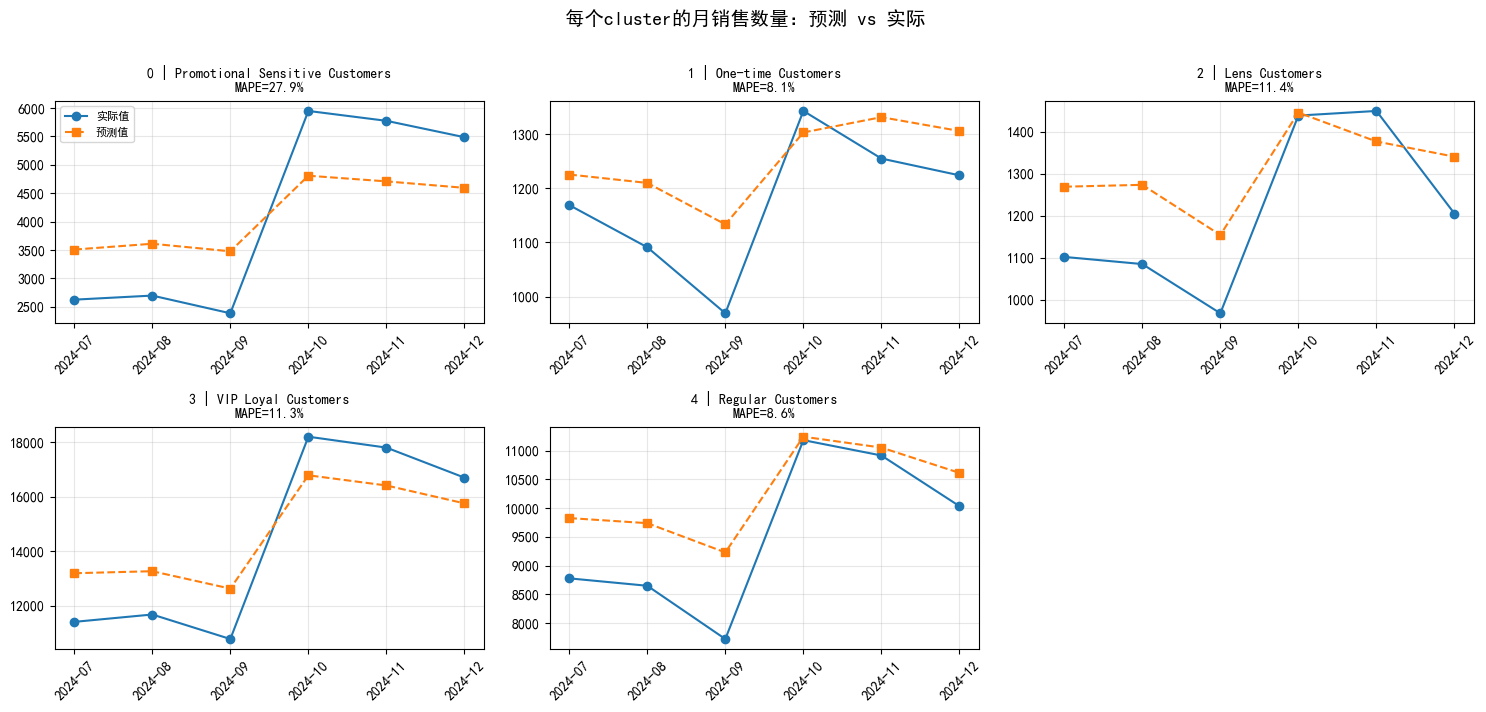

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1) 拼成一张评估表（顺序必须与 test 一致）
df_plot = test[['order_month', 'customer_hierarchy', 'customer_type']].copy()
df_plot['y_true'] = np.asarray(y_test_qty)
df_plot['y_pred'] = np.asarray(pred_final)   # 或 lgm_pred_rev_final / cat_pred_revenue

# 组合 cluster 标识，方便分组和标题
df_plot["cluster"] = (
    df_plot["customer_hierarchy"].astype(str) + " | " + df_plot["customer_type"].astype(str)
)

clusters = sorted(df_plot['cluster'].unique())
n = len(clusters)

# 2) 子图布局：例如 4 列
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.5 * nrows), sharex=False)
axes = np.array(axes).reshape(-1)

for i, cluster in enumerate(clusters):
    ax = axes[i]
    g = (
        df_plot[df_plot['cluster'] == cluster]
        .sort_values('order_month')
    )
    ax.plot(g['order_month'], g['y_true'], marker='o', label='实际值')
    ax.plot(g['order_month'], g['y_pred'], marker='s', linestyle='--', label='预测值')

    title = cluster
    # 单品 MAPE（避免除0）
    mape_i = np.mean(np.abs(g['y_true'] - g['y_pred']) / np.maximum(g['y_true'], 1e-6))
    ax.set_title(f'{title}\nMAPE={mape_i:.1%}', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

# 去掉多余空轴
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('每个cluster的月销售数量：预测 vs 实际', fontsize=14, fontweight='bold', y=1.01)
# fig.tight_layout()
# plt.show()

import os
# output_dir = "output/5-5_lgm_pred_qty_final-figures"
# output_dir = "output/5-5_cat_pred_qty-figures"
output_dir = "output/5-5_prophet_pred_qty-figures"

os.makedirs(output_dir, exist_ok=True)
fig.tight_layout()
fig.savefig(
    os.path.join(output_dir, "customer_cluster_pred_vs_actual.png"),
    dpi=200,
    bbox_inches="tight"
)
plt.show()


### data vis 2

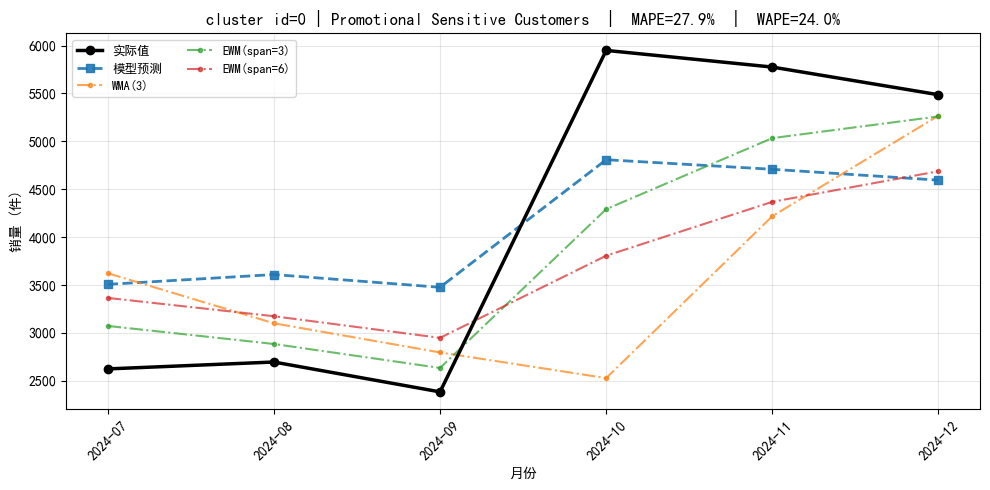

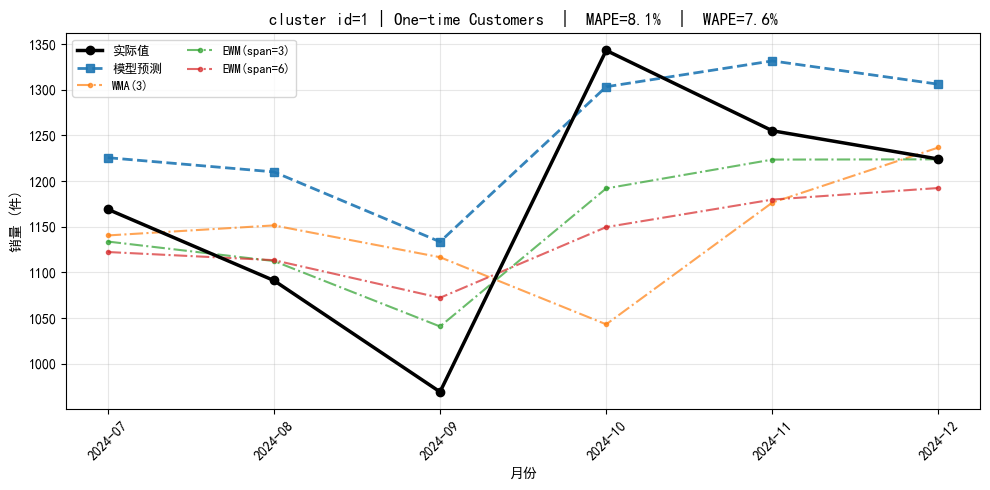

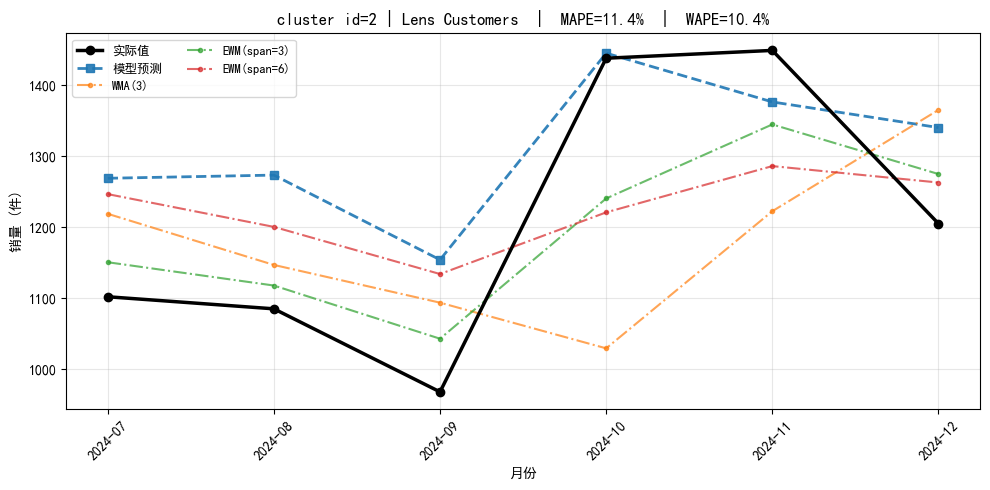

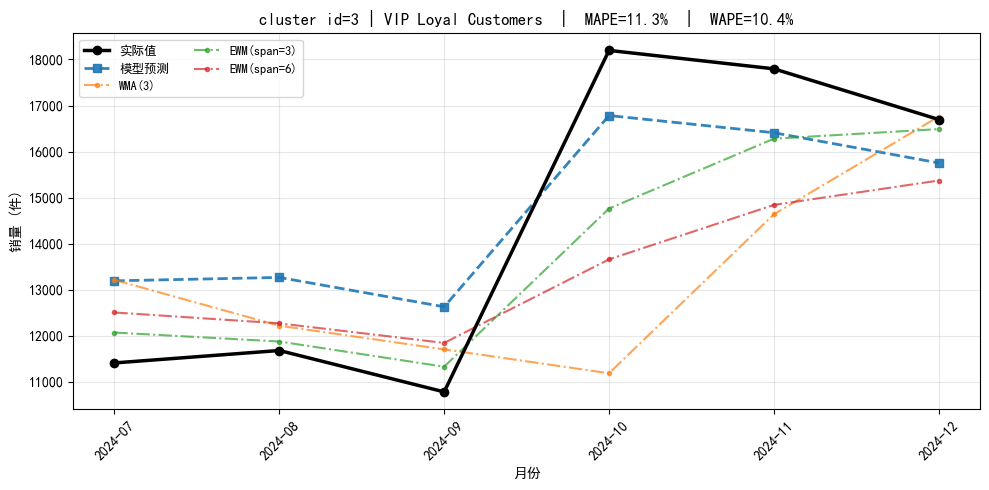

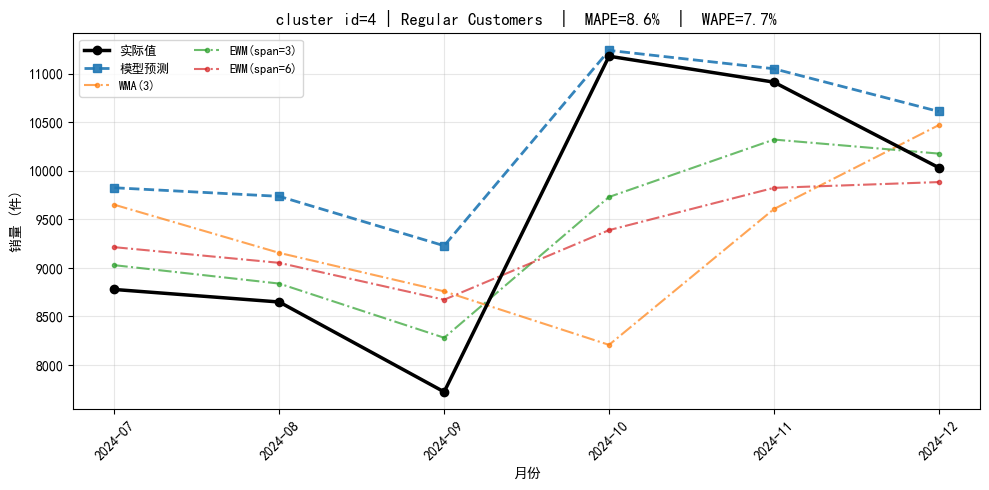

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 1) 预测 vs 真实（与 test 行顺序一致）----------
df_plot = test[['order_month', 'customer_hierarchy', 'customer_type']].copy()
df_plot['y_true'] = np.asarray(y_test_qty)
df_plot['y_pred'] = np.asarray(pred_final)  # 或 lgm_pred_qty_final / cat_pred_qty

df_plot["cluster"] = (
    df_plot["customer_hierarchy"].astype(str)
    + " | "
    + df_plot["customer_type"].astype(str)
)

# ---------- 2) Baseline：按 product_id + order_month 对齐 ----------
baseline_cols = [
    'order_month',  'customer_hierarchy', 'customer_type',
    'wma_3', 'ewm_3', 'ewm_6',
]
baseline_cols = [c for c in baseline_cols if c in df_timeseries_features.columns]

df_base = df_timeseries_features[baseline_cols].copy()

df_plot = df_plot.merge(df_base, on=['order_month', 'customer_hierarchy', 'customer_type'], how='left')
df_plot = df_plot.sort_values(['customer_hierarchy', 'customer_type', 'order_month']).reset_index(drop=True)


# 要画的 baseline 列（存在才画）
baseline_plot_cols = [
    c for c in ['wma_3', 'ewm_3', 'ewm_6',
                'rolling_3_month_avg_quantity', 'rolling_6_month_avg_quantity',
                'historical_mean', 'historical_median']
    if c in df_plot.columns
]

# baseline 显示名
baseline_labels = {
    'wma_3': 'WMA(3)',
    'ewm_3': 'EWM(span=3)',
    'ewm_6': 'EWM(span=6)',
    'rolling_3_month_avg_quantity': '3月滚动均值',
    'rolling_6_month_avg_quantity': '6月滚动均值',
    'historical_mean': '历史均值',
    'historical_median': '历史中位数',
}

clusters = sorted(df_plot['cluster'].unique())

import os,re
# output_dir = "output/5-5_lgm_pred_qty_final-figures"
# output_dir = "output/5-5_cat_pred_qty-figures"
output_dir = "output/5-5_prophet_pred_qty-figures"

def sanitize_filename(name):
    return re.sub(r'[<>:"/\\|?*]', '_', str(name))

os.makedirs(output_dir, exist_ok=True)

# ---------- 3) 每个产品单独一张图 ----------
for cluster in clusters:
    g = df_plot[df_plot['cluster'] == cluster].sort_values('order_month')

    plt.figure(figsize=(10, 5))

    # 真实 & 预测
    plt.plot(g['order_month'], g['y_true'],
             marker='o', linewidth=2.5, color='black', label='实际值', zorder=10)
    plt.plot(g['order_month'], g['y_pred'],
             marker='s', linewidth=2, linestyle='--', label='模型预测', alpha=0.9)

    # baselines
    for col in baseline_plot_cols:
        plt.plot(
            g['order_month'], g[col],
            marker='.', linewidth=1.5, linestyle='-.',
            alpha=0.7, label=baseline_labels.get(col, col)
        )

    # 单品 MAPE
    mape_i = np.mean(
        np.abs(g['y_true'] - g['y_pred']) / np.maximum(g['y_true'].astype(float), 1e-6)
    )
    wape_i = (
            np.abs(g["y_true"] - g["y_pred"]).sum()
            / np.maximum(g["y_true"].astype(float).sum(), 1e-6)
        )
    
    title_str = f"cluster id={cluster}  |  MAPE={mape_i:.1%}  |  WAPE={wape_i:.1%}"
    
    plt.title(title_str, fontsize=12, fontweight='bold')
    plt.xlabel('月份')
    plt.ylabel('销量 (件)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best', fontsize=9, ncol=2)
    filename = os.path.join(output_dir, f"cluster_{sanitize_filename(cluster)}_pred_vs_actual.png")
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()


### output the actual and predict results into a file - v2

In [52]:
import os
import numpy as np
import pandas as pd

os.makedirs("output", exist_ok=True)

# =========================
# 1) 先准备输出主表
# =========================
# 这里要求 test 里至少有 product_id、order_month
assert "customer_hierarchy" in test.columns, "test 中必须包含 customer_hierarchy 列"
assert "order_month" in test.columns, "test 中必须包含 order_month 列"

# 2) 测试月份对应的 baseline（按销量字段）
baseline_cols = [
    "rolling_3_month_avg_quantity",
    "rolling_6_month_avg_quantity",
    "wma_3",
    "ewm_3",
    "ewm_6",
]

baseline_data_test = (
    df_timeseries_features[
        df_timeseries_features["order_month"].isin(test["order_month"].astype(str).values)
    ]
    .sort_values(["order_month", "customer_hierarchy"])
    .reset_index(drop=True)
    [["order_month", "customer_hierarchy"] + baseline_cols]
    .copy()
)
baseline_data_test["order_month"] = baseline_data_test["order_month"].astype(str)


# 真实值：如果你当前 test 表中本身已经是 product_month 粒度，则可以直接用 test['customer_paid_quantity']
# 如果不是，则这里用 y_test_qty 逐行对应
# 这一步的关键：先保留每一行原始记录
base_df = test[["customer_hierarchy", "order_month"]].copy()
base_df["actual_monthly_quantity"] = np.asarray(y_test_qty, dtype=float)

# 预测值（按行对齐）
base_df["lightgbm_pred"] = np.asarray(lgm_pred_qty_final, dtype=float)
base_df["catboost_pred"] = np.asarray(cat_pred_qty, dtype=float)

# 校准后的值
base_df["lightgbm_pred_calibrated"] = (
    np.asarray(lgm_pred_qty_calibrated, dtype=float)
    if "lgm_pred_qty_calibrated" in locals()
    else np.asarray(lgm_pred_qty_final, dtype=float)
)
base_df["catboost_pred_calibrated"] = (
    np.asarray(cat_pred_qty_calibrated, dtype=float)
    if "cat_pred_qty_calibrated" in locals()
    else np.asarray(cat_pred_qty, dtype=float)
)


# 如果你还有 Prophet 结果
if "prophet_pred_qty" in locals():
    base_df["prophet_pred"] = np.asarray(prophet_pred_qty, dtype=float)
else:
    base_df["prophet_pred"] = np.nan

# 你的最终预测值
# 你可以换成 weighted blend / catboost / lightgbm 等
if "pred_final" in locals():
    base_df["final_pred"] = np.asarray(pred_final, dtype=float)
else:
    base_df["final_pred"] = base_df["catboost_pred"]

# =========================
# 2) 按 customer_hierarchy + order_month 聚合
# =========================
agg_df = (
    base_df.groupby(["customer_hierarchy", "order_month"], as_index=False)
    .agg({
        "actual_monthly_quantity": "sum",
        "lightgbm_pred": "sum",
        "catboost_pred": "sum",
        "prophet_pred": "sum",
        "lightgbm_pred_calibrated": "sum",
        "catboost_pred_calibrated": "sum",
        "final_pred": "sum"
    })
)


agg_df = agg_df.merge(
    baseline_data_test,
    on=["order_month", "customer_hierarchy"],
    how="left"
)

# =========================
# 3) 计算误差指标
# =========================
agg_df["lightgbm_mae"] = np.abs(agg_df["lightgbm_pred"] - agg_df["actual_monthly_quantity"])
agg_df["lightgbm_mape"] = np.abs(
    (agg_df["lightgbm_pred"] - agg_df["actual_monthly_quantity"])
    / agg_df["actual_monthly_quantity"].replace(0, np.nan)
)

agg_df["catboost_mae"] = np.abs(agg_df["catboost_pred"] - agg_df["actual_monthly_quantity"])
agg_df["catboost_mape"] = np.abs(
    (agg_df["catboost_pred"] - agg_df["actual_monthly_quantity"])
    / agg_df["actual_monthly_quantity"].replace(0, np.nan)
)

agg_df["prophet_mae"] = np.abs(agg_df["prophet_pred"] - agg_df["actual_monthly_quantity"])
agg_df["prophet_mape"] = np.abs(
    (agg_df["prophet_pred"] - agg_df["actual_monthly_quantity"])
    / agg_df["actual_monthly_quantity"].replace(0, np.nan)
)

agg_df["final_mae"] = np.abs(agg_df["final_pred"] - agg_df["actual_monthly_quantity"])
agg_df["final_mape"] = np.abs(
    (agg_df["final_pred"] - agg_df["actual_monthly_quantity"])
    / agg_df["actual_monthly_quantity"].replace(0, np.nan)
)

# =========================
# 4) 排序
# =========================

# 重新按 month + actual 排序
df_hot_customer_cluster_month = (
    agg_df
    .sort_values(["order_month", "actual_monthly_quantity"], ascending=[True, False])
    .reset_index(drop=True)
)

print(df_hot_customer_cluster_month.head(20))

# =========================
# 5) 导出
# =========================
df_hot_customer_cluster_month.to_parquet(
    "output/5-5-each_month_customer_cluster_sale_qty_prediction.parquet",
    index=False,
    engine="fastparquet"
)

print("已保存 parquet 文件: output/5-5-each_month_customer_cluster_sale_qty_prediction.parquet")
df_hot_customer_cluster_month

   customer_hierarchy order_month  actual_monthly_quantity  lightgbm_pred  \
0                   3     2024-07                  11408.0   10584.837706   
1                   4     2024-07                   8778.0    9025.353974   
2                   0     2024-07                   2623.0    2979.267146   
3                   1     2024-07                   1169.0    1227.223574   
4                   2     2024-07                   1102.0    1489.405760   
5                   3     2024-08                  11678.0   11693.902199   
6                   4     2024-08                   8649.0    9901.796002   
7                   0     2024-08                   2695.0    3028.202605   
8                   1     2024-08                   1091.0    1118.567619   
9                   2     2024-08                   1085.0    1405.607029   
10                  3     2024-09                  10779.0   11446.173019   
11                  4     2024-09                   7723.0    7182.459455   

,customer_hierarchy,order_month,actual_monthly_quantity,lightgbm_pred,catboost_pred,prophet_pred,lightgbm_pred_calibrated,catboost_pred_calibrated,final_pred,rolling_3_month_avg_quantity,...,ewm_3,ewm_6,lightgbm_mae,lightgbm_mape,catboost_mae,catboost_mape,prophet_mae,prophet_mape,final_mae,final_mape
0,3,2024-07,11408.0,10584.837706,12656.901152,13191.336364,10585.191425,12753.077660,13191.336364,13396.000000,...,12068.387722,12504.328644,823.162294,0.072157,1248.901152,0.109476,1783.336364,0.156323,1783.336364,0.156323
1,4,2024-07,8778.0,9025.353974,9636.276348,9825.808122,9025.707693,9732.452856,9825.808122,9769.666667,...,9028.224873,9213.751009,247.353974,0.028179,858.276348,0.097776,1047.808122,0.119368,1047.808122,0.119368
2,0,2024-07,2623.0,2979.267146,3319.190078,3506.151490,2979.620866,3415.366586,3506.151490,3668.000000,...,3071.948368,3364.721911,356.267146,0.135824,696.190078,0.265417,883.151490,0.336695,883.151490,0.336695
3,1,2024-07,1169.0,1227.223574,1302.074886,1225.515341,1227.577293,1398.251394,1225.515341,1147.000000,...,1133.662601,1122.193582,58.223574,0.049806,133.074886,0.113837,56.515341,0.048345,56.515341,0.048345
4,2,2024-07,1102.0,1489.405760,1312.566752,1268.901763,1489.759479,1408.743260,1268.901763,1246.000000,...,1150.626389,1246.589524,387.405760,0.351548,210.566752,0.191077,166.901763,0.151454,166.901763,0.151454
5,3,2024-08,11678.0,11693.902199,12546.209099,13265.358098,11694.255918,12642.385607,13265.358098,12706.666667,...,11873.193861,12268.234745,15.902199,0.001362,868.209099,0.074346,1587.358098,0.135927,1587.358098,0.135927
6,4,2024-08,8649.0,9901.796002,9660.672872,9737.398676,9902.149721,9756.849380,9737.398676,9441.666667,...,8838.612436,9052.393578,1252.796002,0.144849,1011.672872,0.116970,1088.398676,0.125841,1088.398676,0.125841
7,0,2024-08,2695.0,3028.202605,2991.949782,3608.799012,3028.556324,3088.126290,3608.799012,3304.000000,...,2883.474184,3173.372793,333.202605,0.123637,296.949782,0.110185,913.799012,0.339072,913.799012,0.339072
8,1,2024-08,1091.0,1118.567619,1207.782711,1209.941471,1118.921338,1303.959219,1209.941471,1160.666667,...,1112.331301,1113.281130,27.567619,0.025268,116.782711,0.107042,118.941471,0.109021,118.941471,0.109021
9,2,2024-08,1085.0,1405.607029,1313.088396,1273.354522,1405.960748,1409.264904,1273.354522,1191.333333,...,1117.813194,1200.421089,320.607029,0.295490,228.088396,0.210220,188.354522,0.173599,188.354522,0.173599


In [53]:
import gc
gc.collect()

1592

In [37]:
# 关闭数据库连接
engine.dispose()